In [1]:
# ============================================
# PART 1: SETUP AND IMPORTS
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                            VotingClassifier, ExtraTreesClassifier)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix, 
                           classification_report, f1_score)
from sklearn.impute import SimpleImputer

# Setting seed for reproducible results
RANDOM_STATE = 42
N_JOBS = -1
CV_FOLDS = 5

print("="*60)
print("SPACESHIP TITANIC - PREDICTION MODEL")
print("="*60)
print("✓ Libraries loaded successfully!")


SPACESHIP TITANIC - PREDICTION MODEL
✓ Libraries loaded successfully!


In [2]:
# ============================================
# PART 2: LOAD DATA
# ============================================
print("\n" + "="*60)
print("LOADING DATA")
print("="*60)

train = pd.read_csv('/kaggle/input/competitions/dev-comm-jc-2026/train.csv')
test = pd.read_csv('/kaggle/input/competitions/dev-comm-jc-2026/test.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/dev-comm-jc-2026/sample_submission.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

# Display basic info
print("\n--- Missing Values in Training Data ---")
missing = train.isnull().sum()
missing = missing[missing > 0]
for col, count in missing.items():
    print(f"  {col}: {count} ({count/len(train)*100:.1f}%)")



LOADING DATA
Train shape: (8693, 14)
Test shape: (4277, 13)
Sample submission shape: (4277, 2)

--- Missing Values in Training Data ---
  HomePlanet: 201 (2.3%)
  CryoSleep: 217 (2.5%)
  Cabin: 199 (2.3%)
  Destination: 182 (2.1%)
  Age: 179 (2.1%)
  VIP: 203 (2.3%)
  RoomService: 181 (2.1%)
  FoodCourt: 183 (2.1%)
  ShoppingMall: 208 (2.4%)
  Spa: 183 (2.1%)
  VRDeck: 188 (2.2%)
  Name: 200 (2.3%)



EXPLORATORY DATA ANALYSIS


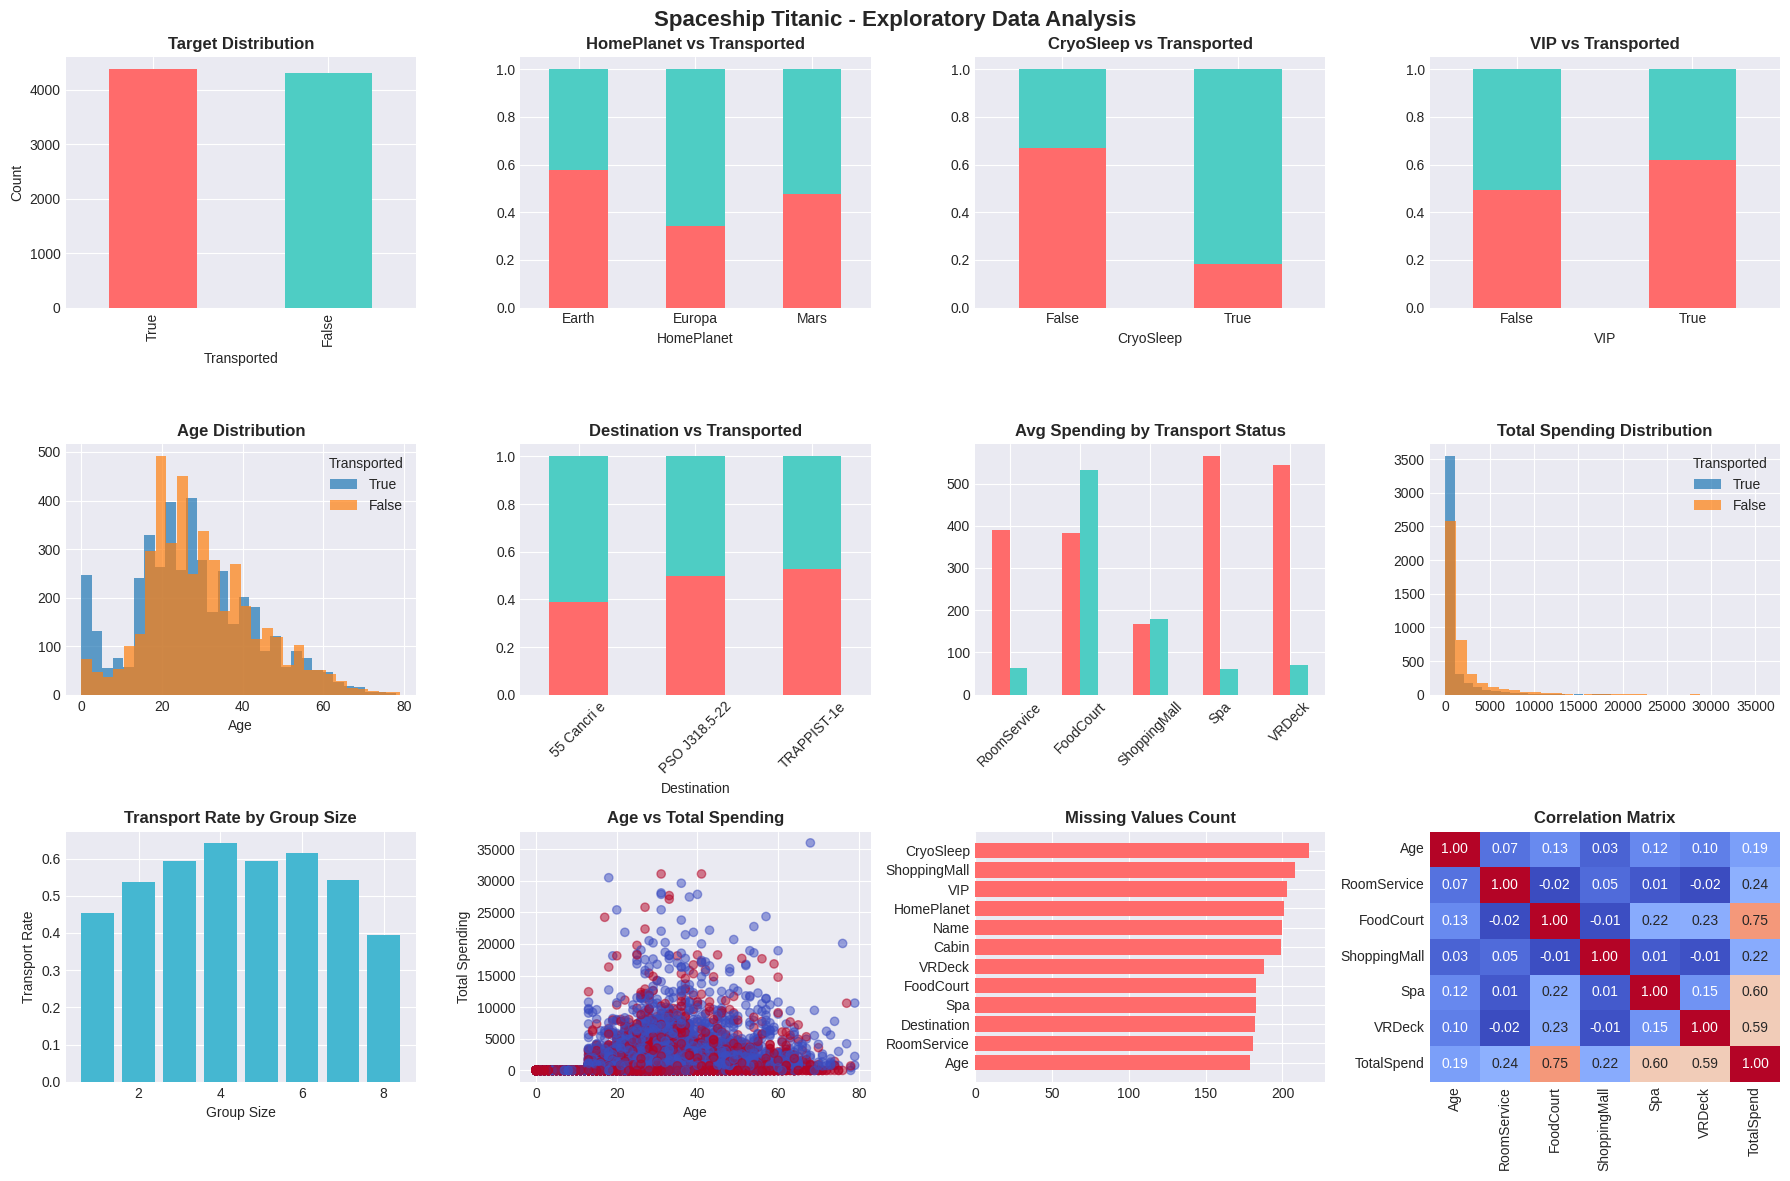

In [3]:
# ============================================
# PART 3: EXPLORATORY DATA ANALYSIS
# ============================================
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

# 1. Target Distribution
train['Transported'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#FF6B6B', '#4ECDC4'])
axes[0,0].set_title('Target Distribution', fontweight='bold')
axes[0,0].set_xlabel('Transported')
axes[0,0].set_ylabel('Count')

# 2. HomePlanet vs Transported
temp = pd.crosstab(train['HomePlanet'], train['Transported'], normalize='index')
temp.plot(kind='bar', stacked=True, ax=axes[0,1], color=['#FF6B6B', '#4ECDC4'])
axes[0,1].set_title('HomePlanet vs Transported', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend().set_visible(False)

# 3. CryoSleep vs Transported
temp = pd.crosstab(train['CryoSleep'], train['Transported'], normalize='index')
temp.plot(kind='bar', stacked=True, ax=axes[0,2], color=['#FF6B6B', '#4ECDC4'])
axes[0,2].set_title('CryoSleep vs Transported', fontweight='bold')
axes[0,2].tick_params(axis='x', rotation=0)
axes[0,2].legend().set_visible(False)

# 4. VIP vs Transported
temp = pd.crosstab(train['VIP'], train['Transported'], normalize='index')
temp.plot(kind='bar', stacked=True, ax=axes[0,3], color=['#FF6B6B', '#4ECDC4'])
axes[0,3].set_title('VIP vs Transported', fontweight='bold')
axes[0,3].tick_params(axis='x', rotation=0)
axes[0,3].legend().set_visible(False)

# 5. Age Distribution
for transported in [True, False]:
    data = train[train['Transported'] == transported]['Age'].dropna()
    axes[1,0].hist(data, alpha=0.7, label=f'{transported}', bins=30)
axes[1,0].set_title('Age Distribution', fontweight='bold')
axes[1,0].set_xlabel('Age')
axes[1,0].legend(title='Transported')

# 6. Destination vs Transported
temp = pd.crosstab(train['Destination'], train['Transported'], normalize='index')
temp.plot(kind='bar', stacked=True, ax=axes[1,1], color=['#FF6B6B', '#4ECDC4'])
axes[1,1].set_title('Destination vs Transported', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend().set_visible(False)

# 7. Average Spending
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
spending_mean = train.groupby('Transported')[spending_cols].mean()
spending_mean.T.plot(kind='bar', ax=axes[1,2], color=['#FF6B6B', '#4ECDC4'])
axes[1,2].set_title('Avg Spending by Transport Status', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].legend().set_visible(False)

# 8. Total Spending Distribution
train['TotalSpend'] = train[spending_cols].sum(axis=1)
for transported in [True, False]:
    data = train[train['Transported'] == transported]['TotalSpend'].dropna()
    axes[1,3].hist(data, alpha=0.7, label=f'{transported}', bins=30)
axes[1,3].set_title('Total Spending Distribution', fontweight='bold')
axes[1,3].legend(title='Transported')

# 9. Group Size Analysis
train['GroupId'] = train['PassengerId'].str.split('_').str[0]
group_size = train['GroupId'].value_counts()
train['GroupSize'] = train['GroupId'].map(group_size)
group_rate = train.groupby('GroupSize')['Transported'].mean()
axes[2,0].bar(group_rate.index, group_rate.values, color='#45B7D1')
axes[2,0].set_title('Transport Rate by Group Size', fontweight='bold')
axes[2,0].set_xlabel('Group Size')
axes[2,0].set_ylabel('Transport Rate')

# 10. Age vs Total Spending
axes[2,1].scatter(train['Age'], train['TotalSpend'], 
                 c=train['Transported'].astype(int), alpha=0.5, cmap='coolwarm')
axes[2,1].set_title('Age vs Total Spending', fontweight='bold')
axes[2,1].set_xlabel('Age')
axes[2,1].set_ylabel('Total Spending')

# 11. Missing Values
missing_sorted = train.isnull().sum().sort_values(ascending=True)
missing_sorted = missing_sorted[missing_sorted > 0]
axes[2,2].barh(range(len(missing_sorted)), missing_sorted.values, color='#FF6B6B')
axes[2,2].set_yticks(range(len(missing_sorted)))
axes[2,2].set_yticklabels(missing_sorted.index)
axes[2,2].set_title('Missing Values Count', fontweight='bold')

# 12. Correlation Heatmap
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend']
corr = train[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2,3], cbar=False)
axes[2,3].set_title('Correlation Matrix', fontweight='bold')

plt.suptitle('Spaceship Titanic - Exploratory Data Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Clean up temporary columns
train.drop(['TotalSpend', 'GroupId', 'GroupSize'], axis=1, inplace=True)


In [4]:
# ============================================
# PART 4: MISSING VALUE HANDLING (BEFORE FEATURE ENGINEERING)
# ============================================
print("\n" + "="*60)
print("HANDLING MISSING VALUES")
print("="*60)

def handle_missing_values(df, is_train=True, train_df=None):
    """
    Handle missing values BEFORE feature engineering.
    This prevents NaN issues during feature creation.
    """
    df = df.copy()
    
    # 1. Handle boolean columns first (convert to int after filling)
    bool_columns = ['CryoSleep', 'VIP']
    for col in bool_columns:
        if col in df.columns:
            # Fill NaN with False (most common)
            df[col] = df[col].fillna(False)
            # Convert to int (0/1)
            df[col] = df[col].astype(bool).astype(int)
    
    # 2. Handle numeric columns with median
    numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in numeric_cols:
        if col in df.columns:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
    
    # 3. Handle categorical columns with mode
    categorical_cols = ['HomePlanet', 'Cabin', 'Destination', 'Name']
    for col in categorical_cols:
        if col in df.columns:
            mode_val = df[col].mode()
            if len(mode_val) > 0:
                df[col] = df[col].fillna(mode_val[0])
            else:
                df[col] = df[col].fillna('Unknown')
    
    # 4. Handle Target (only in training data)
    if 'Transported' in df.columns:
        df['Transported'] = df['Transported'].astype(int)
    
    # Verify no missing values remain
    remaining_missing = df.isnull().sum().sum()
    if remaining_missing > 0:
        print(f"  Warning: {remaining_missing} missing values remain!")
        # Final fill for any remaining NaN
        df = df.fillna(0)
    
    return df

# Apply missing value handling
train_clean = handle_missing_values(train, is_train=True)
test_clean = handle_missing_values(test, is_train=False)

print(f"✓ Train missing values after cleaning: {train_clean.isnull().sum().sum()}")
print(f"✓ Test missing values after cleaning: {test_clean.isnull().sum().sum()}")


HANDLING MISSING VALUES
✓ Train missing values after cleaning: 0
✓ Test missing values after cleaning: 0


In [5]:
# ============================================
# PART 5: FEATURE ENGINEERING
# ============================================
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

def create_features(df):
    """
    Create features from cleaned data (no NaN values).
    """
    df = df.copy()
    
    # --- Cabin Features ---
    print("  → Cabin features...")
    cabin_split = df['Cabin'].str.split('/', expand=True)
    df['Deck'] = cabin_split[0].fillna('Unknown')
    df['CabinNum'] = pd.to_numeric(cabin_split[1], errors='coerce').fillna(0)
    df['Side'] = cabin_split[2].fillna('Unknown')
    
    # Encode cabin features
    deck_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'T': 0, 'Unknown': -1}
    df['DeckNum'] = df['Deck'].map(deck_map).astype(int)
    df['SideNum'] = df['Side'].map({'P': 0, 'S': 1, 'Unknown': -1}).astype(int)
    
    # --- Passenger Grouping ---
    print("  → Passenger grouping...")
    df['GroupId'] = df['PassengerId'].str.split('_').str[0].astype(int)
    df['PassengerNum'] = df['PassengerId'].str.split('_').str[1].astype(int)
    
    # --- Spending Features ---
    print("  → Spending features...")
    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    
    df['TotalSpending'] = df[spending_cols].sum(axis=1)
    df['HasSpending'] = (df['TotalSpending'] > 0).astype(int)
    df['ServicesUsed'] = (df[spending_cols] > 0).sum(axis=1)
    df['AvgSpending'] = df['TotalSpending'] / 5
    
    # Spending ratios
    for col in spending_cols:
        df[f'{col}_Ratio'] = (df[col] / (df['TotalSpending'] + 1)).round(4)
    
    # Luxury vs Necessity
    df['LuxurySpending'] = df['Spa'] + df['VRDeck']
    df['NecessitySpending'] = df['RoomService'] + df['FoodCourt']
    df['LuxuryRatio'] = (df['LuxurySpending'] / (df['TotalSpending'] + 1)).round(4)
    
    # --- Age Features ---
    print("  → Age features...")
    # Age categories (as numeric codes)
    bins = [0, 12, 18, 25, 35, 50, 65, 120]
    df['AgeCategory'] = pd.cut(df['Age'], bins=bins, labels=False)
    
    df['AgeSquared'] = df['Age'] ** 2
    df['AgeLog'] = np.log(df['Age'] + 1)
    df['IsMinor'] = (df['Age'] < 18).astype(int)
    df['IsSenior'] = (df['Age'] > 60).astype(int)
    
    # --- Interaction Features ---
    print("  → Interaction features...")
    df['CryoAge'] = df['CryoSleep'] * df['Age']
    df['VIPSpending'] = df['VIP'] * df['TotalSpending']
    df['DeckSide'] = df['DeckNum'] * df['SideNum']
    df['CryoSpending'] = df['CryoSleep'] * df['TotalSpending']
    
    # --- Statistical Features ---
    print("  → Statistical features...")
    df['SpendingStd'] = df[spending_cols].std(axis=1)
    df['SpendingMax'] = df[spending_cols].max(axis=1)
    df['SpendingMin'] = df[spending_cols].min(axis=1)
    df['SpendingRange'] = df['SpendingMax'] - df['SpendingMin']
    
    return df

# Apply feature engineering
train_fe = create_features(train_clean)
test_fe = create_features(test_clean)

print(f"\n✓ Feature engineering complete!")
print(f"  Train features: {train_fe.shape[1]} columns")
print(f"  Test features: {test_fe.shape[1]} columns")


FEATURE ENGINEERING
  → Cabin features...
  → Passenger grouping...
  → Spending features...
  → Age features...
  → Interaction features...
  → Statistical features...
  → Cabin features...
  → Passenger grouping...
  → Spending features...
  → Age features...
  → Interaction features...
  → Statistical features...

✓ Feature engineering complete!
  Train features: 46 columns
  Test features: 45 columns


In [6]:
# ============================================
# PART 6: GROUP-BASED FEATURES
# ============================================
print("\n" + "="*60)
print("GROUP-BASED FEATURES")
print("="*60)

def add_group_features(train_df, test_df):
    """Add group-based aggregate features"""
    
    # Combine datasets
    combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
    
    # Group size
    group_size = combined.groupby('GroupId').size().reset_index(name='GroupSize')
    
    # Merge group size
    train_df = train_df.merge(group_size, on='GroupId', how='left')
    test_df = test_df.merge(group_size, on='GroupId', how='left')
    
    # IsAlone
    train_df['IsAlone'] = (train_df['GroupSize'] == 1).astype(int)
    test_df['IsAlone'] = (test_df['GroupSize'] == 1).astype(int)
    
    # Group aggregates for spending
    agg_cols = ['TotalSpending', 'RoomService', 'FoodCourt', 'Spa', 'VRDeck', 'Age']
    
    for col in agg_cols:
        if col in combined.columns:
            # Calculate group statistics
            group_stats = combined.groupby('GroupId')[col].agg(['mean', 'std']).reset_index()
            group_stats.columns = ['GroupId', f'Group_{col}_Mean', f'Group_{col}_Std']
            # Fill NaN std with 0 (for groups of size 1)
            group_stats[f'Group_{col}_Std'] = group_stats[f'Group_{col}_Std'].fillna(0)
            
            # Merge
            train_df = train_df.merge(group_stats, on='GroupId', how='left')
            test_df = test_df.merge(group_stats, on='GroupId', how='left')
    
    # Group demographic ratios
    for col in ['CryoSleep', 'VIP']:
        if col in combined.columns:
            group_ratio = combined.groupby('GroupId')[col].mean().reset_index(name=f'Group_{col}_Ratio')
            train_df = train_df.merge(group_ratio, on='GroupId', how='left')
            test_df = test_df.merge(group_ratio, on='GroupId', how='left')
    
    # Fill any NaN from merges
    train_df = train_df.fillna(0)
    test_df = test_df.fillna(0)
    
    return train_df, test_df

train_fe, test_fe = add_group_features(train_fe, test_fe)

print(f"✓ Group features added!")
print(f"  Train features: {train_fe.shape[1]} columns")


GROUP-BASED FEATURES
✓ Group features added!
  Train features: 62 columns


In [7]:
# ============================================
# PART 7: PREPARE FOR MODELING
# ============================================
print("\n" + "="*60)
print("PREPARING FOR MODELING")
print("="*60)

def prepare_data(train_df, test_df, target_col='Transported'):
    """Encode categoricals and create final feature matrix"""
    
    # Columns to drop (identifiers and raw text)
    drop_cols = ['PassengerId', 'Name', 'Cabin', 'Deck', 'Side', 'GroupId']
    drop_cols = [c for c in drop_cols if c in train_df.columns]
    
    # Separate target
    if target_col in train_df.columns:
        y = train_df[target_col].copy()
        X_train = train_df.drop(columns=drop_cols + [target_col])
    else:
        y = None
        X_train = train_df.drop(columns=drop_cols)
    
    X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
    
    # Encode any remaining categorical columns
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
    
    for col in cat_cols:
        le = LabelEncoder()
        # Fit on combined data to handle all categories
        combined = pd.concat([X_train[col].astype(str), X_test[col].astype(str)])
        le.fit(combined)
        X_train[col] = le.transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
    
    # Ensure all numeric and fill any remaining NaN
    X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
    X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
    
    print(f"  Final features: {X_train.shape[1]}")
    
    return X_train, X_test, y

X_train_full, X_test_full, y_train_full = prepare_data(train_fe, test_fe)

print(f"✓ Data ready for modeling!")
print(f"  X_train: {X_train_full.shape}")
print(f"  X_test: {X_test_full.shape}")


PREPARING FOR MODELING
  Final features: 55
✓ Data ready for modeling!
  X_train: (8693, 55)
  X_test: (4277, 55)



FEATURE SELECTION
✓ Selected 47 features (importance > 0.005)

Top 15 Features:
  CabinNum                       0.0798
  TotalSpending                  0.0476
  SpendingMax                    0.0472
  ServicesUsed                   0.0418
  SpendingStd                    0.0370
  LuxuryRatio                    0.0347
  AvgSpending                    0.0321
  HasSpending                    0.0279
  Group_Age_Mean                 0.0277
  DeckNum                        0.0276
  RoomService_Ratio              0.0276
  FoodCourt_Ratio                0.0259
  SpendingRange                  0.0252
  LuxurySpending                 0.0250
  Age                            0.0246


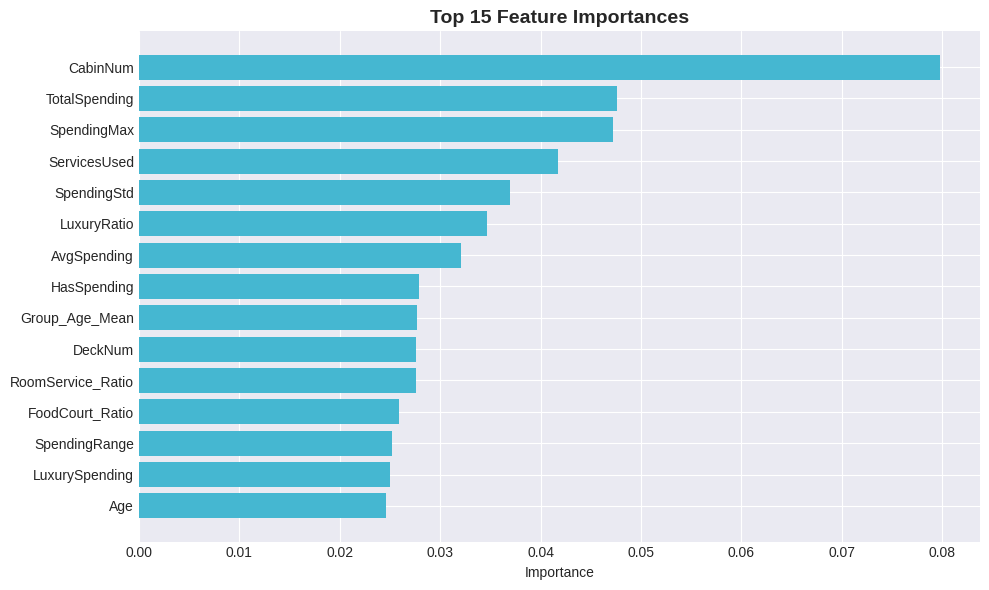

In [8]:
# ============================================
# PART 8: FEATURE SELECTION
# ============================================
print("\n" + "="*60)
print("FEATURE SELECTION")
print("="*60)

# Get feature importance from Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=N_JOBS)
rf.fit(X_train_full, y_train_full)

feature_imp = pd.DataFrame({
    'feature': X_train_full.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Select top features (importance > 0.005)
selected = feature_imp[feature_imp['importance'] > 0.005]['feature'].tolist()
print(f"✓ Selected {len(selected)} features (importance > 0.005)")

# Display top 15
print("\nTop 15 Features:")
for i, row in feature_imp.head(15).iterrows():
    print(f"  {row['feature']:<30} {row['importance']:.4f}")

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
top15 = feature_imp.head(15)
ax.barh(range(len(top15)), top15['importance'].values, color='#45B7D1')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['feature'].values)
ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Use selected features
X_train_sel = X_train_full[selected]
X_test_sel = X_test_full[selected]

In [9]:
# ============================================
# PART 9: TRAIN AND EVALUATE MODELS
# ============================================
print("\n" + "="*60)
print("MODEL TRAINING")
print("="*60)

# Split for validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sel, y_train_full, test_size=0.2, 
    random_state=RANDOM_STATE, stratify=y_train_full
)

print(f"Training: {X_tr.shape[0]} | Validation: {X_val.shape[0]}")

# Scale features
scaler = RobustScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test_sel)

# Define models
models = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=N_JOBS, eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        random_seed=RANDOM_STATE, verbose=False
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=5,
        random_state=RANDOM_STATE, n_jobs=N_JOBS
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, random_state=RANDOM_STATE
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=200, max_depth=10, min_samples_split=5,
        random_state=RANDOM_STATE, n_jobs=N_JOBS
    )
}

# Train and evaluate
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results = {}

print("\n--- Model Performance ---")
for name, model in models.items():
    # CV scores
    cv_scores = cross_val_score(model, X_tr_s, y_tr, cv=cv, scoring='accuracy', n_jobs=N_JOBS)
    
    # Train
    model.fit(X_tr_s, y_tr)
    
    # Validate
    val_pred = model.predict(X_val_s)
    val_proba = model.predict_proba(X_val_s)[:, 1]
    
    results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'accuracy': accuracy_score(y_val, val_pred),
        'auc': roc_auc_score(y_val, val_proba),
        'f1': f1_score(y_val, val_pred)
    }
    
    print(f"\n{name}:")
    print(f"  CV: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"  Val Accuracy: {results[name]['accuracy']:.4f}")
    print(f"  Val AUC: {results[name]['auc']:.4f}")
    print(f"  Val F1: {results[name]['f1']:.4f}")

# Find best model
best_name = max(results, key=lambda x: results[x]['auc'])
best_model = results[best_name]['model']
print(f"\n✓ Best individual model: {best_name} (AUC: {results[best_name]['auc']:.4f})")


MODEL TRAINING
Training: 6954 | Validation: 1739

--- Model Performance ---

XGBoost:
  CV: 0.8053 (±0.0070)
  Val Accuracy: 0.8045
  Val AUC: 0.9046
  Val F1: 0.8050


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM:
  CV: 0.8095 (±0.0050)
  Val Accuracy: 0.8125
  Val AUC: 0.9072
  Val F1: 0.8139

CatBoost:
  CV: 0.8121 (±0.0063)
  Val Accuracy: 0.8062
  Val AUC: 0.9076
  Val F1: 0.8120

RandomForest:
  CV: 0.7995 (±0.0094)
  Val Accuracy: 0.7959
  Val AUC: 0.8876
  Val F1: 0.8031

GradientBoosting:
  CV: 0.8051 (±0.0081)
  Val Accuracy: 0.8056
  Val AUC: 0.9051
  Val F1: 0.8088

ExtraTrees:
  CV: 0.7991 (±0.0065)
  Val Accuracy: 0.7964
  Val AUC: 0.8822
  Val F1: 0.8018

✓ Best individual model: CatBoost (AUC: 0.9076)


In [10]:
# ============================================
# PART 10: ENSEMBLE
# ============================================
print("\n" + "="*60)
print("ENSEMBLE MODEL")
print("="*60)

# Top 3 models for ensemble
top3 = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)[:3]
print("Top 3 models:")
for name, res in top3:
    print(f"  {name}: AUC = {res['auc']:.4f}")

# Voting ensemble
ensemble = VotingClassifier(
    estimators=[(name, res['model']) for name, res in top3],
    voting='soft'
)
ensemble.fit(X_tr_s, y_tr)

# Evaluate ensemble
ens_pred = ensemble.predict(X_val_s)
ens_proba = ensemble.predict_proba(X_val_s)[:, 1]
ens_auc = roc_auc_score(y_val, ens_proba)
ens_acc = accuracy_score(y_val, ens_pred)

print(f"\nEnsemble Performance:")
print(f"  Accuracy: {ens_acc:.4f}")
print(f"  AUC: {ens_auc:.4f}")

# Choose final model
if ens_auc > results[best_name]['auc']:
    final_model = ensemble
    final_name = "Voting Ensemble"
    print(f"\n✓ Using Voting Ensemble (AUC: {ens_auc:.4f})")
else:
    final_model = best_model
    final_name = best_name
    print(f"\n✓ Using {best_name} (AUC: {results[best_name]['auc']:.4f})")


ENSEMBLE MODEL
Top 3 models:
  CatBoost: AUC = 0.9076
  LightGBM: AUC = 0.9072
  GradientBoosting: AUC = 0.9051

Ensemble Performance:
  Accuracy: 0.8062
  AUC: 0.9084

✓ Using Voting Ensemble (AUC: 0.9084)



MODEL VISUALIZATION


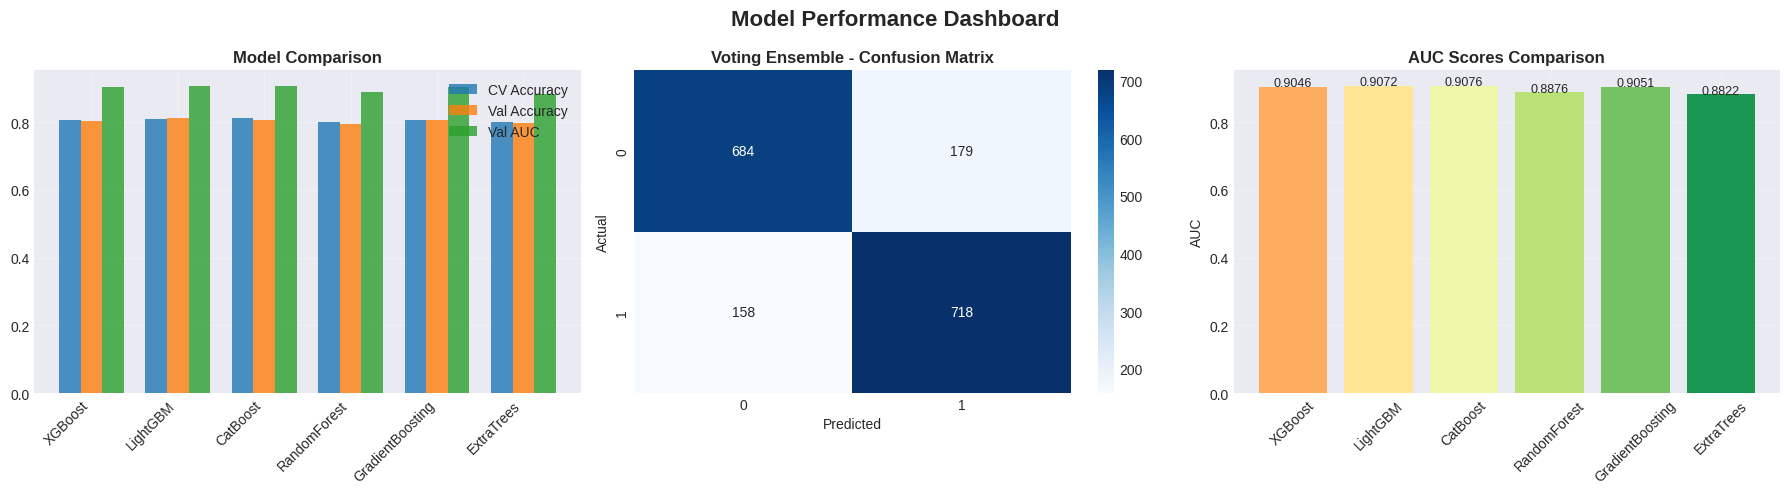

In [11]:
# ============================================
# PART 11: MODEL VISUALIZATION
# ============================================
print("\n" + "="*60)
print("MODEL VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Model Comparison
names = list(results.keys())
x = np.arange(len(names))
width = 0.25

axes[0].bar(x - width, [results[n]['cv_mean'] for n in names], width, label='CV Accuracy', alpha=0.8)
axes[0].bar(x, [results[n]['accuracy'] for n in names], width, label='Val Accuracy', alpha=0.8)
axes[0].bar(x + width, [results[n]['auc'] for n in names], width, label='Val AUC', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=45, ha='right')
axes[0].set_title('Model Comparison', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Confusion Matrix
cm = confusion_matrix(y_val, final_model.predict(X_val_s))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'{final_name} - Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# 3. AUC Scores
auc_scores = [results[n]['auc'] for n in names]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(names)))
bars = axes[2].bar(names, auc_scores, color=colors)
axes[2].set_title('AUC Scores Comparison', fontweight='bold')
axes[2].set_ylabel('AUC')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(alpha=0.3)
for bar, val in zip(bars, auc_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                f'{val:.4f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [12]:
# ============================================
# PART 12: FINAL TRAINING & PREDICTIONS
# ============================================
print("\n" + "="*60)
print("FINAL TRAINING AND PREDICTIONS")
print("="*60)

# Scale full data
scaler_final = RobustScaler()
X_train_full_s = scaler_final.fit_transform(X_train_sel)
X_test_full_s = scaler_final.transform(X_test_sel)

# Train on full data
final_model.fit(X_train_full_s, y_train_full)

# Cross-validation on full data
final_cv = cross_val_score(final_model, X_train_full_s, y_train_full, 
                           cv=CV_FOLDS, scoring='accuracy', n_jobs=N_JOBS)
print(f"Final CV Accuracy: {final_cv.mean():.4f} (±{final_cv.std():.4f})")

# Generate predictions
test_proba = final_model.predict_proba(X_test_full_s)[:, 1]

# Optimize threshold
print("\nOptimizing threshold...")
best_f1 = 0
best_thresh = 0.5
val_proba_final = final_model.predict_proba(X_val_s)[:, 1]

for t in np.arange(0.4, 0.6, 0.01):
    pred_t = (val_proba_final >= t).astype(int)
    f1_t = f1_score(y_val, pred_t)
    if f1_t > best_f1:
        best_f1 = f1_t
        best_thresh = t

print(f"Optimal threshold: {best_thresh:.3f} (F1: {best_f1:.4f})")

# Apply threshold
test_pred = (test_proba >= best_thresh).astype(bool)

print(f"\nPredictions:")
print(f"  Transported: {test_pred.sum()} ({test_pred.sum()/len(test_pred)*100:.1f}%)")
print(f"  Not Transported: {(~test_pred).sum()} ({(~test_pred).sum()/len(test_pred)*100:.1f}%)")


FINAL TRAINING AND PREDICTIONS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Final CV Accuracy: 0.7883 (±0.0246)

Optimizing threshold...
Optimal threshold: 0.430 (F1: 0.8903)

Predictions:
  Transported: 2399 (56.1%)
  Not Transported: 1878 (43.9%)


In [13]:
# ============================================
# PART 13: SUBMISSION
# ============================================
print("\n" + "="*60)
print("CREATING SUBMISSION")
print("="*60)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_pred
})

submission.to_csv('submission.csv', index=False)

print("✓ Submission saved: submission.csv")
print(f"  Shape: {submission.shape}")
print(f"\nFirst 10 rows:")
print(submission.head(10).to_string(index=False))


CREATING SUBMISSION
✓ Submission saved: submission.csv
  Shape: (4277, 2)

First 10 rows:
PassengerId  Transported
    0013_01         True
    0018_01        False
    0019_01         True
    0021_01         True
    0023_01         True
    0027_01         True
    0029_01         True
    0032_01         True
    0032_02         True
    0033_01         True


In [14]:
# ============================================
# PART 14: SUMMARY
# ============================================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

# Calculate percentages
transported_pct = (test_pred.sum() / len(test_pred) * 100)
not_transported_pct = ((~test_pred).sum() / len(test_pred) * 100)

print(f"""
FINAL MODEL: {final_name}
FEATURES USED: {len(selected)}
CV ACCURACY: {final_cv.mean():.4f} (±{final_cv.std():.4f})
OPTIMAL THRESHOLD: {best_thresh:.3f}

TOP 5 MODELS:
""")

# Print top 5 models
for i, (name, res) in enumerate(sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)[:5]):
    print(f"  {i+1}. {name}: AUC={res['auc']:.4f}, Acc={res['accuracy']:.4f}")

print(f"""
PREDICTION DISTRIBUTION:
  Transported: {test_pred.sum()} ({transported_pct:.1f}%)
  Not Transported: {(~test_pred).sum()} ({not_transported_pct:.1f}%)

SUBMISSION FILE: submission.csv

✅ ANALYSIS COMPLETE!
""")
print("="*60)


SUMMARY

FINAL MODEL: Voting Ensemble
FEATURES USED: 47
CV ACCURACY: 0.7883 (±0.0246)
OPTIMAL THRESHOLD: 0.430

TOP 5 MODELS:

  1. CatBoost: AUC=0.9076, Acc=0.8062
  2. LightGBM: AUC=0.9072, Acc=0.8125
  3. GradientBoosting: AUC=0.9051, Acc=0.8056
  4. XGBoost: AUC=0.9046, Acc=0.8045
  5. RandomForest: AUC=0.8876, Acc=0.7959

PREDICTION DISTRIBUTION:
  Transported: 2399 (56.1%)
  Not Transported: 1878 (43.9%)

SUBMISSION FILE: submission.csv

✅ ANALYSIS COMPLETE!

